In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, brier_score_loss, roc_auc_score, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import TimeSeriesSplit

In [2]:
df = pd.read_csv('df.csv')

In [3]:
split = int(len(df) * 0.8)

train_df = df.iloc[:split]
test_df = df.iloc[split:]

X_train = train_df.drop(columns=['target'])
y_train = train_df['target']

X_test = test_df.drop(columns=['target'])
y_test = test_df['target']

In [4]:
varians = X_train.var(numeric_only=True)
n_largest_varians = varians.nlargest(3).index.tolist()

X_train = X_train[n_largest_varians]
X_test = X_test[n_largest_varians]

In [5]:
#Trening og Evaluering av modellen

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Brier Score Loss:", brier_score_loss(y_test, y_pred_proba[:, 1]))
print("ROC AUC Score:", roc_auc_score(y_test, y_pred_proba[:, 1]))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.4819277108433735
Brier Score Loss: 0.2553383036315682
ROC AUC Score: 0.44300822561692127
Classification Report:
               precision    recall  f1-score   support

           0       0.44      0.65      0.53        37
           1       0.55      0.35      0.43        46

    accuracy                           0.48        83
   macro avg       0.50      0.50      0.48        83
weighted avg       0.50      0.48      0.47        83



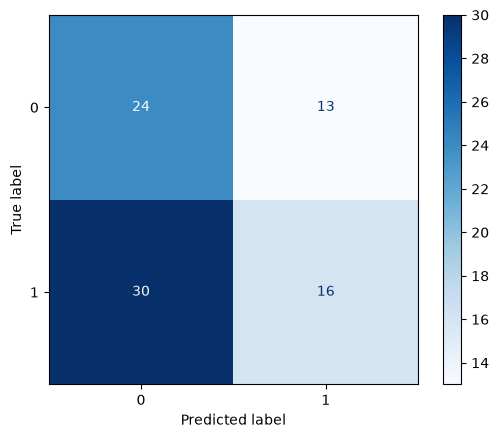

In [11]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap=plt.cm.Blues)

plt.show()

In [12]:
#PREDIKASJON

print(y_pred[-1])
print(y_pred_proba[-1])

0
[0.50898009 0.49101991]


In [15]:
#Predikasjoner på treningsett
y_pred_train = model.predict(X_train)
y_proba_train = model.predict_proba(X_train)[:, 1]

#Predikasjoner på testsett
y_pred_test = model.predict(X_test)
y_proba_test = model.predict_proba(X_test)[:, 1]

print("Train Accuracy:", accuracy_score(y_train, y_pred_train))
print("Test Accuracy:", accuracy_score(y_test, y_pred_test))

print("Train AUC Score:", roc_auc_score(y_train, y_proba_train))
print("Test AUC Score:", roc_auc_score(y_test, y_proba_test))

Train Accuracy: 0.5180722891566265
Test Accuracy: 0.4819277108433735
Train AUC Score: 0.5144145126695023
Test AUC Score: 0.44300822561692127


In [13]:
#Overfitting
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

target
1    0.521084
0    0.478916
Name: proportion, dtype: float64
target
1    0.554217
0    0.445783
Name: proportion, dtype: float64


In [19]:
#Walk-Forward Testing: TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)

X = None
y = None
model = None

X = df.drop(columns=['target'])
y = df['target']

accuracies = []
aucs = []

scaler = StandardScaler()

for train_i, test_i in tscv.split(X):
    X_train = X.iloc[train_i]
    X_test =  X.iloc[test_i]

    y_train = y.iloc[train_i]
    y_test =  y.iloc[test_i]

    # Standardize the features
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    model = LogisticRegression()

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    #Evaluering
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)

    accuracies.append(acc)
    aucs.append(auc)

    print(f"Accuracy: {acc:.3f}")
    print(f"AUC: {auc:.3f}")
    print("-" * 30)

    print(f"\nGjennomsnitt:")
    print(f"Accuracy: {np.mean(accuracies):.3f}")
    print(f"AUC: {np.mean(aucs):.3f}")

Accuracy: 0.580
AUC: 0.493
------------------------------

Gjennomsnitt:
Accuracy: 0.580
AUC: 0.493
Accuracy: 0.449
AUC: 0.435
------------------------------

Gjennomsnitt:
Accuracy: 0.514
AUC: 0.464
Accuracy: 0.493
AUC: 0.523
------------------------------

Gjennomsnitt:
Accuracy: 0.507
AUC: 0.484
Accuracy: 0.449
AUC: 0.471
------------------------------

Gjennomsnitt:
Accuracy: 0.493
AUC: 0.481
Accuracy: 0.464
AUC: 0.675
------------------------------

Gjennomsnitt:
Accuracy: 0.487
AUC: 0.519
